<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 158.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 182.7 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 92.8 MB/s eta 0:00:00


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-06-07 12:35:46--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  33.9MB/s    in 6.1s    

2026-06-07 12:35:53 (24.8 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



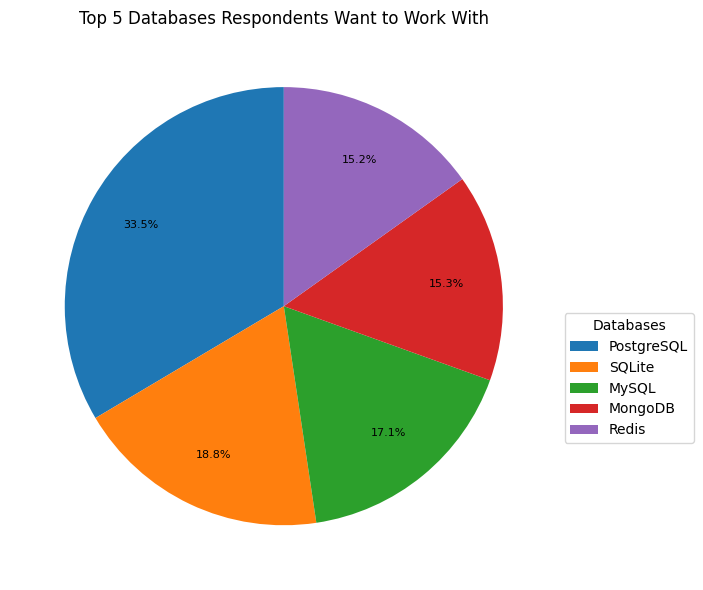

In [4]:
##Write your code here
#Columns -DatabaseWantToWorkWith - want the top 5 
Data_df = df[['DatabaseWantToWorkWith']].copy()

#Standardise
Data_df['DatabaseWantToWorkWith'] = Data_df['DatabaseWantToWorkWith'].astype(str).str.strip()

#splitting into seperate rows
Data_exploded = Data_df.assign(DatabaseWantToWorkWith=Data_df['DatabaseWantToWorkWith'].str.split(';')).explode('DatabaseWantToWorkWith')

#clean more after exploding
Data_exploded['DatabaseWantToWorkWith'] = Data_exploded['DatabaseWantToWorkWith'].str.strip()

#Remove missing values
Data_exploded = Data_exploded.dropna()

#Get top5
top_databases_counts = Data_exploded['DatabaseWantToWorkWith'].value_counts().head(5)

#Plot pie
fig, ax = plt.subplots(figsize=(10,6))

wedges, texts, autotexts = ax.pie(
    top_databases_counts.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 8})

ax.set_title('Top 5 Databases Respondents Want to Work With')
ax.set_ylabel('')

ax.legend(
    wedges,
    top_databases_counts.index,
    title='Databases',
    loc='upper left',
    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



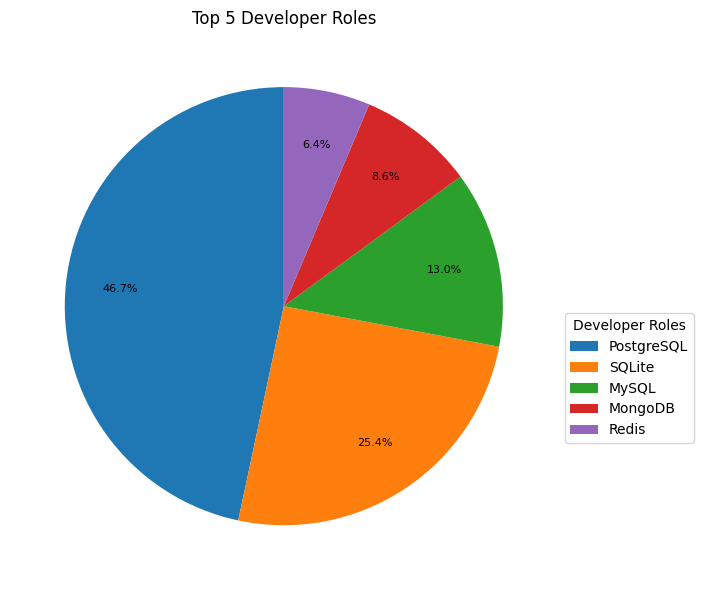

In [5]:
##Write your code here
#column DevType - Top5

Developer_df = df[['DevType']].copy()

#Standardise
Developer_df['DevType'] = Developer_df['DevType'].astype(str).str.strip()

#splitting into seperate rows
Developer_exploded = Developer_df.assign(DevType=Developer_df['DevType'].str.split(';')).explode('DevType')

#clean more after exploding
Developer_exploded['DevType'] = Developer_exploded['DevType'].str.strip()

#Remove missing values
Developer_exploded = Developer_exploded.dropna()

#Get top5
top_developer_counts = Developer_exploded['DevType'].value_counts().head(5)

#Plot pie
fig, ax = plt.subplots(figsize=(10,6))

wedges, texts, autotexts = ax.pie(
    top_developer_counts.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 8})

ax.set_title('Top 5 Developer Roles')
ax.set_ylabel('')

ax.legend(
    wedges,
    top_databases_counts.index,
    title='Developer Roles',
    loc='upper left',
    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



In [6]:
df.columns.tolist()

['ResponseId',
 'MainBranch',
 'Age',
 'Employment',
 'RemoteWork',
 'Check',
 'CodingActivities',
 'EdLevel',
 'LearnCode',
 'LearnCodeOnline',
 'TechDoc',
 'YearsCode',
 'YearsCodePro',
 'DevType',
 'OrgSize',
 'PurchaseInfluence',
 'BuyNewTool',
 'BuildvsBuy',
 'TechEndorse',
 'Country',
 'Currency',
 'CompTotal',
 'LanguageHaveWorkedWith',
 'LanguageWantToWorkWith',
 'LanguageAdmired',
 'DatabaseHaveWorkedWith',
 'DatabaseWantToWorkWith',
 'DatabaseAdmired',
 'PlatformHaveWorkedWith',
 'PlatformWantToWorkWith',
 'PlatformAdmired',
 'WebframeHaveWorkedWith',
 'WebframeWantToWorkWith',
 'WebframeAdmired',
 'EmbeddedHaveWorkedWith',
 'EmbeddedWantToWorkWith',
 'EmbeddedAdmired',
 'MiscTechHaveWorkedWith',
 'MiscTechWantToWorkWith',
 'MiscTechAdmired',
 'ToolsTechHaveWorkedWith',
 'ToolsTechWantToWorkWith',
 'ToolsTechAdmired',
 'NEWCollabToolsHaveWorkedWith',
 'NEWCollabToolsWantToWorkWith',
 'NEWCollabToolsAdmired',
 'OpSysPersonal use',
 'OpSysProfessional use',
 'OfficeStackAsyncHa

In [7]:
df['OpSysProfessional use'].unique()

<StringArray>
[                                                                                                                                nan,
                                                                                                                             'MacOS',
                                                                                                                           'Windows',
                                                                                         'Windows;Windows Subsystem for Linux (WSL)',
                                                                                                 'Windows Subsystem for Linux (WSL)',
                                                                                  'Ubuntu;Windows;Windows Subsystem for Linux (WSL)',
                                                                                                                   'Red Hat;Windows',
                                                

In [8]:
#change the column name 
df = df.rename(columns={'OpSysProfessional use': 'opsysprofessional_use'})

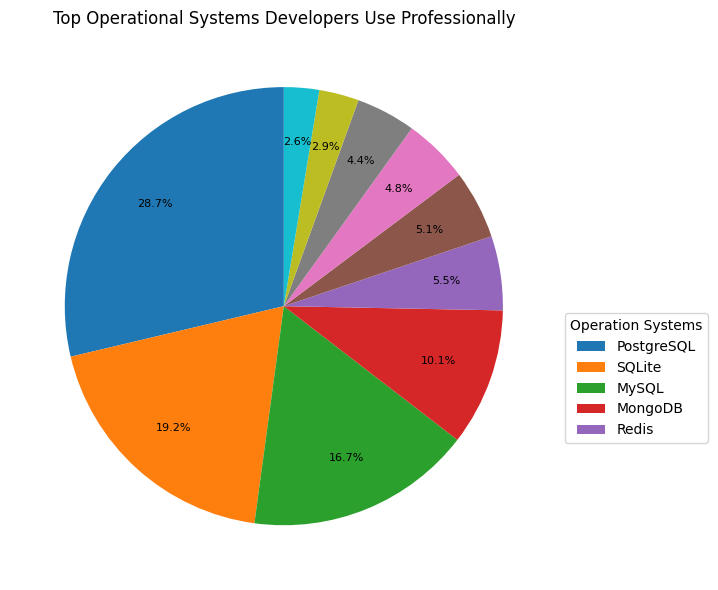

In [9]:
##Write your code here
#column opsysprofessional_use (OS) - Top

OS_df = df[['opsysprofessional_use']].copy()

#Standardise
OS_df['opsysprofessional_use'] = OS_df['opsysprofessional_use'].astype(str).str.strip()

#splitting into seperate rows
OS_exploded = OS_df.assign(opsysprofessional_use=OS_df['opsysprofessional_use'].str.split(';')).explode('opsysprofessional_use')

#clean more after exploding
OS_exploded['opsysprofessional_use'] = OS_exploded['opsysprofessional_use'].str.strip()

#Remove missing values
OS_exploded = OS_exploded.dropna()

#Get top5
top_OS_counts = OS_exploded['opsysprofessional_use'].value_counts().head(10)

#Plot pie
fig, ax = plt.subplots(figsize=(10,6))

wedges, texts, autotexts = ax.pie(
    top_OS_counts.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 8})

ax.set_title('Top Operational Systems Developers Use Professionally')
ax.set_ylabel('')

ax.legend(
    wedges,
    top_databases_counts.index,
    title='Operation Systems',
    loc='upper left',
    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



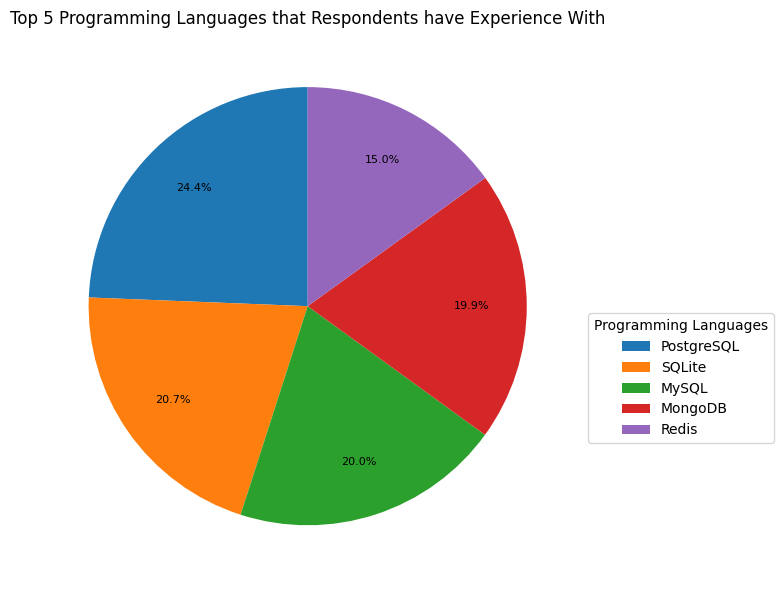

In [10]:
##Write your code here
#Column = languagehaveworkedwith (Lang) - Top 5 Languages

Lang_df = df[['LanguageHaveWorkedWith']].copy()

#Standardise
Lang_df['LanguageHaveWorkedWith'] = Lang_df['LanguageHaveWorkedWith'].astype(str).str.strip()

#splitting into seperate rows
Lang_exploded = Lang_df.assign(LanguageHaveWorkedWith=Lang_df['LanguageHaveWorkedWith'].str.split(';')).explode('LanguageHaveWorkedWith')

#clean more after exploding
Lang_exploded['LanguageHaveWorkedWith'] = Lang_exploded['LanguageHaveWorkedWith'].str.strip()

#Remove missing values
Lang_exploded = Lang_exploded.dropna()

#Get top5
top_PLanguages_counts = Lang_exploded['LanguageHaveWorkedWith'].value_counts().head(5)

#Plot pie
fig, ax = plt.subplots(figsize=(10,6))

wedges, texts, autotexts = ax.pie(
    top_PLanguages_counts.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 8})

ax.set_title('Top 5 Programming Languages that Respondents have Experience With')
ax.set_ylabel('')

ax.legend(
    wedges,
    top_databases_counts.index,
    title='Programming Languages',
    loc='upper left',
    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



In [11]:
df['NEWCollabToolsHaveWorkedWith'].unique()

<StringArray>
[                                                                                                                      nan,
                                                                                     'PyCharm;Visual Studio Code;WebStorm',
                                                                                                           'Visual Studio',
                                                                                                                     'Vim',
                                                                                       'Nano;Vim;Visual Studio Code;Xcode',
                                                                                                                 'RStudio',
                                                                                                      'Visual Studio Code',
                  'Android Studio;IntelliJ IDEA;Netbeans;Notepad++;Sublime Text;Visual Studio;Visual Studio Code;WebSt

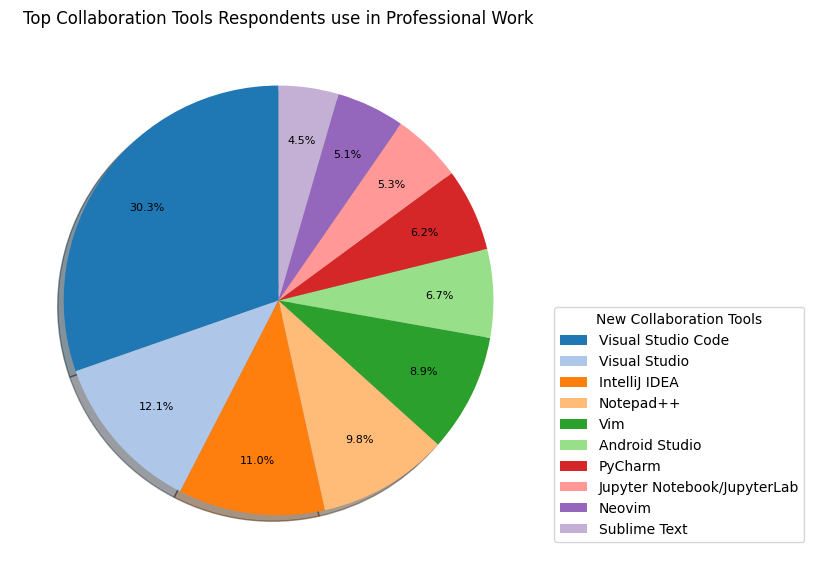

In [12]:
##Write your code here
#Column = 'NEWCollabToolsHaveWorkedWith' (Newcollab) - Top 10 Languages

Newcollab_df = df[['NEWCollabToolsHaveWorkedWith']].copy()

Newcollab_df = Newcollab_df.dropna()

#Standardise
Newcollab_df['NEWCollabToolsHaveWorkedWith'] = Newcollab_df['NEWCollabToolsHaveWorkedWith'].str.strip()

#splitting into seperate rows
Newcollab_exploded =Newcollab_df.assign(NEWCollabToolsHaveWorkedWith=Newcollab_df['NEWCollabToolsHaveWorkedWith'].str.split(';')).explode('NEWCollabToolsHaveWorkedWith')

#clean more after exploding
Newcollab_exploded['NEWCollabToolsHaveWorkedWith'] = Newcollab_exploded['NEWCollabToolsHaveWorkedWith'].str.strip()
Newcollas_exploded = Newcollab_exploded[Newcollab_exploded['NEWCollabToolsHaveWorkedWith'] != '']
#Remove missing values
Newcollab_exploded = Newcollab_exploded.dropna()

#Get top5
top_Newcollab_counts =(Newcollab_exploded['NEWCollabToolsHaveWorkedWith'].value_counts().head(10).sort_values(ascending=False))

#Plot pie
fig, ax = plt.subplots(figsize=(10,6))
colors = plt.cm.tab20.colors

wedges, texts, autotexts = ax.pie(
    top_Newcollab_counts.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    shadow=True,
    colors = colors,
    textprops={'fontsize': 8})

ax.set_title('Top Collaboration Tools Respondents use in Professional Work')
ax.set_ylabel('')

ax.legend(
    wedges,
    top_Newcollab_counts.index,
    title='New Collaboration Tools',
    loc='upper left',
    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



In [13]:
df['LanguageAdmired'].unique()

<StringArray>
[                                                                                                                     nan,
                                                  'Bash/Shell (all shells);Go;HTML/CSS;Java;JavaScript;Python;TypeScript',
                                                                                                                     'C#',
                                                              'HTML/CSS;Java;JavaScript;PowerShell;Python;SQL;TypeScript',
                                                                                     'C++;HTML/CSS;JavaScript;Lua;Python',
                                               'Bash/Shell (all shells);HTML/CSS;Java;JavaScript;Python;Swift;TypeScript',
                                                                                                                      'R',
                                                                                         'HTML/CSS;JavaScript;TypeScript',
  

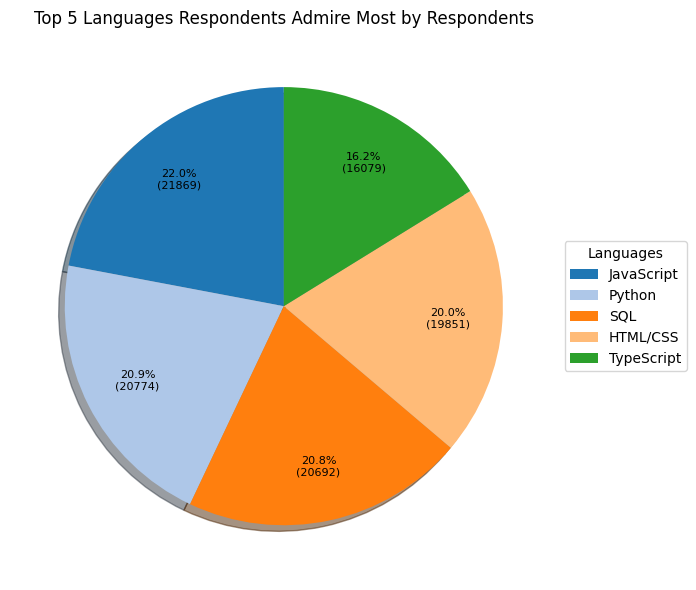

In [14]:
##Write your code here
#Column = LanguageAdmired (LangAd) - Top 10 Languages

LangAd_df = df[['LanguageAdmired']].copy()

LangAd_df = LangAd_df.dropna()

#Standardise
LangAd_df['LanguageAdmired'] = LangAd_df['LanguageAdmired'].str.strip()

#splitting into seperate rows
LangAd_exploded =LangAd_df.assign(LanguageAdmired=LangAd_df['LanguageAdmired'].str.split(';')).explode('LanguageAdmired')

#clean more after exploding
LangAd_exploded['LanguageAdmired'] =LangAd_exploded['LanguageAdmired'].str.strip()
LangAd_exploded = LangAd_exploded[LangAd_exploded['LanguageAdmired'] != '']
#Remove missing values
LangAd_exploded = LangAd_exploded.dropna()

#Get top5
top_LangAd_counts =(LangAd_exploded['LanguageAdmired'].value_counts().head(5).sort_values(ascending=False))

#improing labels showing counts + %
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return inner
    
#Plot pie
fig, ax = plt.subplots(figsize=(10,6))
colors = plt.cm.tab20.colors[:len(top_LangAd_counts)]

wedges, texts, autotexts = ax.pie(
    top_LangAd_counts.values,
    labels=None,
    autopct=autopct_format(top_LangAd_counts.values),
    startangle=90,
    pctdistance=0.75,
    shadow=True,
    colors = colors,
    textprops={'fontsize': 8})

ax.set_title('Top 5 Languages Respondents Admire Most by Respondents')
ax.set_ylabel('')

ax.legend(
    wedges,
    top_LangAd_counts.index,
    title='Languages',
    loc='center left',
    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



In [15]:
df['AIToolCurrently Using'].unique()

<StringArray>
[                                                                                                                                                                                                                                                               nan,
                                                                            'Learning about a codebase;Project planning;Writing code;Documenting code;Debugging and getting help;Deployment and monitoring;Search for answers;Generating content or synthetic data',
                                                                                                                                                                                                                          'Writing code;Debugging and getting help',
                                                                                                                                                                                                       'Wri

In [16]:
#change the column name 
df = df.rename(columns={'AIToolCurrently Using': 'AIToolCurrently_Using'})

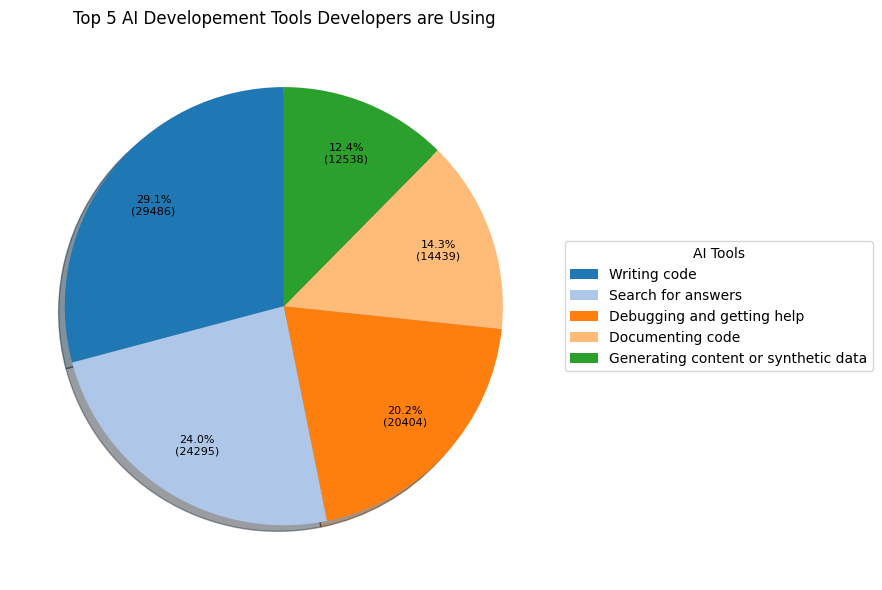

In [17]:
##Write your code here
#Column - AIToolCurrently Using (AITool)

AITool_df = df[['AIToolCurrently_Using']].copy()

AITool_df = AITool_df.dropna()

#Standardise
AITool_df['AIToolCurrently_Using'] =AITool_df['AIToolCurrently_Using'].str.strip()

#splitting into seperate rows
AITool_exploded =AITool_df.assign(AIToolCurrently_Using=AITool_df['AIToolCurrently_Using'].str.split(';')).explode('AIToolCurrently_Using')

#clean more after exploding
AITool_exploded['AIToolCurrently_Using'] =AITool_exploded['AIToolCurrently_Using'].str.strip()
AITool_exploded = AITool_exploded[AITool_exploded['AIToolCurrently_Using'] != '']
#Remove missing values
AITool_exploded = AITool_exploded.dropna()

#Get top5
top_AITool_counts =(AITool_exploded['AIToolCurrently_Using'].value_counts().head(5).sort_values(ascending=False))

#improing labels showing counts + %
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return inner
    
#Plot pie
fig, ax = plt.subplots(figsize=(10,6))
colors = plt.cm.tab20.colors[:len(top_AITool_counts)]

wedges, texts, autotexts = ax.pie(
    top_AITool_counts.values,
    labels=None,
    autopct=autopct_format(top_AITool_counts.values),
    startangle=90,
    pctdistance=0.75,
    shadow=True,
    colors = colors,
    textprops={'fontsize': 8})

ax.set_title('Top 5 AI Developement Tools Developers are Using')
ax.set_ylabel('')

ax.legend(
    wedges,
    top_AITool_counts.index,
    title='AI Tools',
    loc='center left',
    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



In [18]:
df['WebframeWantToWorkWith'].unique()

<StringArray>
[                                                                                                          nan,
                                                                            'Express;Htmx;Node.js;React;Remix',
                                                                                                'ASP.NET CORE',
                                                                                'jQuery;Next.js;Node.js;React',
                                                                                                     'Node.js',
                                                                                               'Next.js;React',
                                                                               'Express;Next.js;Node.js;React',
                                                                          'Django;Node.js;React;Ruby on Rails',
                                                           'ASP.NET;ASP.NET CORE;Express;j

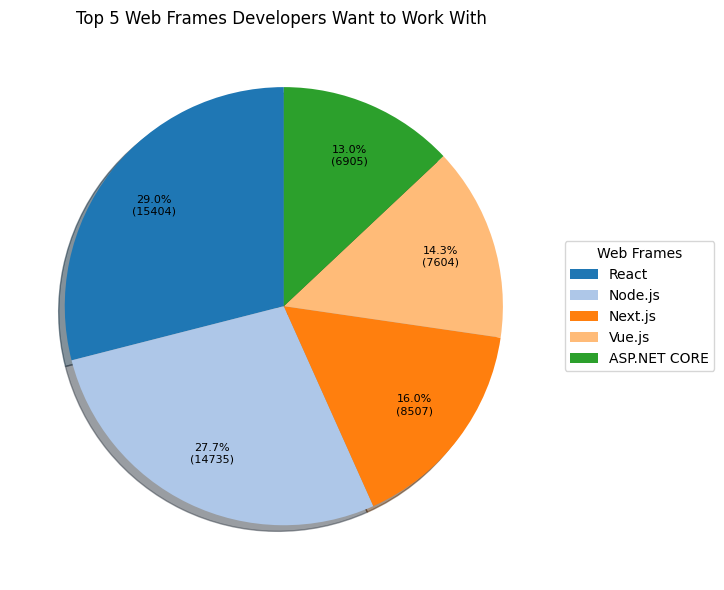

In [21]:
##Write your code here
#Columns WebframeWantToWorkWith (Web) - top5

Web_df = df[['WebframeWantToWorkWith']].copy()

Web_df = Web_df.dropna()

#Standardise
Web_df['WebframeWantToWorkWith'] =Web_df['WebframeWantToWorkWith'].str.strip()

#splitting into seperate rows
Web_exploded =Web_df.assign(WebframeWantToWorkWith=Web_df['WebframeWantToWorkWith'].str.split(';')).explode('WebframeWantToWorkWith')

#clean more after exploding
Web_exploded['WebframeWantToWorkWith'] =Web_exploded['WebframeWantToWorkWith'].str.strip()
Web_exploded = Web_exploded[Web_exploded['WebframeWantToWorkWith'] != '']
#Remove missing values
Web_exploded = Web_exploded.dropna()

#Get top5
top_WebFrame_counts =(Web_exploded['WebframeWantToWorkWith'].value_counts().head(5).sort_values(ascending=False))

#improing labels showing counts + %
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return inner
    
#Plot pie
fig, ax = plt.subplots(figsize=(10,6))
colors = plt.cm.tab20.colors[:len(top_WebFrame_counts)]

wedges, texts, autotexts = ax.pie(
    top_WebFrame_counts.values,
    labels=None,
    autopct=autopct_format(top_WebFrame_counts.values),
    startangle=90,
    pctdistance=0.75,
    shadow=True,
    colors = colors,
    textprops={'fontsize': 8})

ax.set_title('Top 5 Web Frames Developers Want to Work With ')
ax.set_ylabel('')

ax.legend(
    wedges,
    top_WebFrame_counts.index,
    title='Web Frames',
    loc='center left',
    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



In [22]:
df['EmbeddedWantToWorkWith'].unique()

<StringArray>
[                                                                                                                                                 nan,
                                                                                                                                        'Rasberry Pi',
                                                                                                                                  'CMake;Rasberry Pi',
                                                                                                                                'Arduino;Rasberry Pi',
                                                                                                                          'Arduino;CMake;Rasberry Pi',
                                                                                                                                               'MSVC',
                                                                                

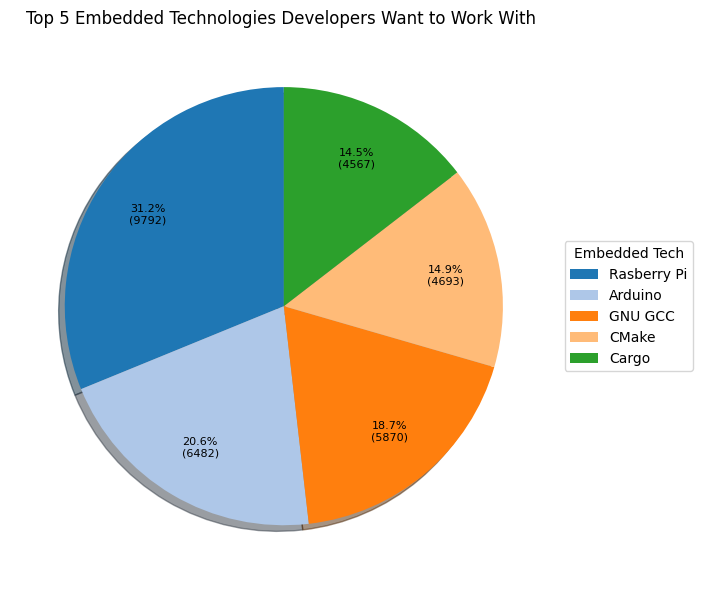

In [23]:
##Write your code here
#columns = EmbeddedWantToWorkWith (Embedded)
Embedded_df = df[['EmbeddedWantToWorkWith']].copy()

Embedded_df = Embedded_df.dropna()

#Standardise
Embedded_df['EmbeddedWantToWorkWith'] =Embedded_df['EmbeddedWantToWorkWith'].str.strip()

#splitting into seperate rows
Embedded_exploded =Embedded_df.assign(EmbeddedWantToWorkWith=Embedded_df['EmbeddedWantToWorkWith'].str.split(';')).explode('EmbeddedWantToWorkWith')

#clean more after exploding
Embedded_exploded['EmbeddedWantToWorkWith'] =Embedded_exploded['EmbeddedWantToWorkWith'].str.strip()
Embedded_exploded = Embedded_exploded[Embedded_exploded['EmbeddedWantToWorkWith'] != '']
#Remove missing values
Embedded_exploded = Embedded_exploded.dropna()

#Get top5
top_EmbeddedTech_counts =(Embedded_exploded['EmbeddedWantToWorkWith'].value_counts().head(5).sort_values(ascending=False))

#improing labels showing counts + %
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return inner
    
#Plot pie
fig, ax = plt.subplots(figsize=(10,6))
colors = plt.cm.tab20.colors[:len(top_EmbeddedTech_counts)]

wedges, texts, autotexts = ax.pie(
    top_EmbeddedTech_counts.values,
    labels=None,
    autopct=autopct_format(top_EmbeddedTech_counts.values),
    startangle=90,
    pctdistance=0.75,
    shadow=True,
    colors = colors,
    textprops={'fontsize': 8})

ax.set_title('Top 5 Embedded Technologies Developers Want to Work With ')
ax.set_ylabel('')

ax.legend(
    wedges,
    top_EmbeddedTech_counts.index,
    title='Embedded Tech',
    loc='center left',
    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
